# Notebook 01: Operational Data Acquisition & Preprocessing (Human Performance)

### 1. Project Overview
This research pioneers an adaptive **Hybrid Digital Twin (HDT)** framework for a Printed Circuit Board (PCB) mass-customization assembly line. Shifting away from rigid deterministic models, this architecture strictly follows the **Industry 5.0 paradigm**, which demands the reintegration of human well-being and stochastic human factors into the Cyber-Physical Production System (CPPS). 

This notebook establishes the empirical foundation of the Human Digital Twin by analyzing performance dynamics across two environments:
* **Manual Workstations (MW):** Traditional assembly tasks performed entirely by human operators.
* **Collaborative Workstations (CW):** Assembly tasks performed through human-robot collaboration (HRC).

### 2. Objectives of this Notebook
This notebook serves as the **Data Preprocessing Pipeline** (as outlined in Methodology Section 2.2.1). The core objectives are:
* **Data Aggregation:** Consolidating raw assembly logs from multiple manual and collaborative stations into a unified operational dataset.
* **Temporal Normalization:** Converting raw timestamps (`hh:mm:ss`) into objective execution metrics (`total_time_sec`).
* **Robust Data Cleaning & Outlier Handling:** Applying the Interquartile Range (IQR) statistical method to filter out extreme temporal anomalies and right-skewed deviations.
* **Statistical Integrity Verification & EDA:** Executing Exploratory Data Analysis (EDA) supplemented by non-parametric hypothesis testing (Mann-Whitney U) to mathematically validate human performance variance.
* **EDA-Driven Complexity Labeling (Leakage-Aware):** Utilizing empirical duration quantiles to categorize assembly cognitive loads (Low, Medium, High) strictly for exploratory visualization, implementing protocols to prevent downstream data leakage in predictive modeling.

### 3. Dataset Description
The primary behavioral dataset is derived from a real-world semi-automated assembly line (Silverline). 
* **Input Format:** CSV operational logs for multiple operators across CW and MW stations.
* **Key Features:** Granular timestamps for specific sub-tasks (Grab, Pick, Robot start/stop, End) and total units processed.

# STEP 1. LIBRARIES & ENVIRONMENT SETUP

In [3]:
import sys
import os
import zipfile
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Print Python version for reproducibility

In [4]:
print(sys.version)

3.13.11 | packaged by Anaconda, Inc. | (main, Dec 10 2025, 21:21:58) [MSC v.1929 64 bit (AMD64)]


## Define the data path

In [5]:
DATA_ZIP = "../data/15340717.zip"
print("ZIP exists:", os.path.exists(DATA_ZIP))

ZIP exists: True


# STEP 2. DATA LOADING FUNCTIONS

In [6]:
def read_csv_from_zip(zip_obj, filename):
    with zip_obj.open(filename) as f:
        return pd.read_csv(f, sep=";", engine="python")

In [7]:
zf = zipfile.ZipFile(DATA_ZIP)

print("Files inside ZIP:")
for f in zf.namelist():
    print(" -", f)

Files inside ZIP:
 - CW2.csv
 - MW4.csv
 - MW2.csv
 - CW1.csv
 - CW4.csv
 - MW1.csv
 - CW3.csv
 - MW3.csv


# STEP 3: DATA PROCESSING & FEATURE ENGINEERING FUNCTIONS

### Convert 'H.MM.SS' (e.g., '0.02.31') to total seconds. 
(Returns NaN for missing/invalid values.)

In [8]:
def time_to_seconds(t):   
    if pd.isna(t):
        return np.nan

    t = str(t).strip()
    parts = t.split(".")

   
    if len(parts) != 3:
        return np.nan

    h, m, s = parts
    try:
        return int(h) * 3600 + int(m) * 60 + int(s)
    except:
        return np.nan

### Processes Collaborative Workstation (CW) data: 
Calculates operational durations and identifies potential idle gaps or overlaps.

In [9]:
def process_cw(df, worker_id):    
    df = df.copy()
    df.columns = df.columns.str.strip()

    # Convert all timestamp columns to seconds
    
    time_cols = ["Grab", "R1 start", "R1 stop", "Pick", "R2 start", "R2 stop", "End"]
    for c in time_cols:
        df[c + "_sec"] = df[c].apply(time_to_seconds)

    # Calculate main operational durations

    df["cw_total_time"] = df["End_sec"] - df["Grab_sec"]
    df["cw_r1_time"] = df["R1 stop_sec"] - df["R1 start_sec"]
    df["cw_r2_time"] = df["R2 stop_sec"] - df["R2 start_sec"]

    # Calculate raw gaps between consecutive tasks

    df["gap_grab_to_r1"] = df["R1 start_sec"] - df["Grab_sec"]
    df["gap_r1_to_pick"] = df["Pick_sec"] - df["R1 stop_sec"]
    df["gap_pick_to_r2"] = df["R2 start_sec"] - df["Pick_sec"]
    df["gap_r2_to_end"]  = df["End_sec"] - df["R2 stop_sec"]

    # Calculate clipped gaps (non-negative) and overlaps (when gap < 0)

    gap_cols = ["gap_grab_to_r1", "gap_r1_to_pick", "gap_pick_to_r2", "gap_r2_to_end"]
    for c in gap_cols:
        df[c + "_clipped"] = df[c].clip(lower=0)
        df[c + "_overlap"] = (-df[c]).clip(lower=0)

    # Append metadata

    df["worker_id"] = worker_id
    df["workstation"] = "CW"

    # Retain relevant features

    keep = [
        "worker_id", "workstation", "Units processed",
        "cw_total_time", "cw_r1_time", "cw_r2_time",
        "gap_grab_to_r1_clipped", "gap_r1_to_pick_clipped", "gap_pick_to_r2_clipped", "gap_r2_to_end_clipped",
        "gap_grab_to_r1_overlap", "gap_r1_to_pick_overlap", "gap_pick_to_r2_overlap", "gap_r2_to_end_overlap"
    ]

    return df[keep]

#### Processes Manual Workstation (MW) data:
Cleans structural issues and calculates total task duration.

In [10]:
def process_mw(df, worker_id):
    df = df.copy()
    df.columns = df.columns.str.strip()

    # Drop trailing unnamed columns often generated by CSV export issues
    df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

    # Handle inconsistent column naming for the final step
    stop_col = "Stop" if "Stop" in df.columns else "End"

    df["Start_sec"] = df["Start"].apply(time_to_seconds)
    df["Stop_sec"]  = df[stop_col].apply(time_to_seconds)

    df["mw_total_time"] = df["Stop_sec"] - df["Start_sec"]

    df["worker_id"] = worker_id
    df["workstation"] = "MW"

    keep = [
        "worker_id", "workstation", "Units processed",
        "mw_total_time"
    ]
    return df[keep]

## STEP 4: DATA AGGREGATION PIPELINE

In [11]:
# Initialize empty lists to store processed dataframes
cw_all = []
mw_all = []

# Iterate through all 4 workers in a single, efficient loop
for i in range(1, 5):
    # Extract and process Collaborative Workstation (CW) data
    cw_df = read_csv_from_zip(zf, f"CW{i}.csv")
    cw_all.append(process_cw(cw_df, worker_id=i))
    
    # Extract and process Manual Workstation (MW) data
    mw_df = read_csv_from_zip(zf, f"MW{i}.csv")
    mw_all.append(process_mw(mw_df, worker_id=i))

# Concatenate lists into single DataFrames
features_CW_all = pd.concat(cw_all, ignore_index=True)
features_MW_all = pd.concat(mw_all, ignore_index=True)

# Clean MW data: Drop NaNs and invalid negative task durations
features_MW_clean = (
    features_MW_all
    .dropna(subset=["mw_total_time"])
    .loc[lambda df: df["mw_total_time"] >= 0]
    .copy()
)

# Combine both CW and MW into a single unified dataset
features_labeled_all = pd.concat([features_CW_all, features_MW_clean], ignore_index=True)

# Create a standardized 'total_time_sec' target column for both stations
if 'total_time_sec' not in features_labeled_all.columns:
    features_labeled_all['total_time_sec'] = features_labeled_all['cw_total_time'].fillna(features_labeled_all['mw_total_time'])

# Display final shapes to verify the pipeline execution
print("CW shape:", features_CW_all.shape)
print("MW (Cleaned) shape:", features_MW_clean.shape)
print("Unified Dataset shape:", features_labeled_all.shape)

# Preview the final unified dataset
features_labeled_all.head()

CW shape: (906, 14)
MW (Cleaned) shape: (913, 4)
Unified Dataset shape: (1819, 16)


,worker_id,workstation,Units processed,cw_total_time,cw_r1_time,cw_r2_time,gap_grab_to_r1_clipped,gap_r1_to_pick_clipped,gap_pick_to_r2_clipped,gap_r2_to_end_clipped,gap_grab_to_r1_overlap,gap_r1_to_pick_overlap,gap_pick_to_r2_overlap,gap_r2_to_end_overlap,mw_total_time,total_time_sec
0,1,CW,1.0,141.0,35.0,31.0,19.0,14.0,22.0,20.0,0.0,0.0,0.0,0.0,NaN,141.0
1,1,CW,2.0,142.0,35.0,30.0,10.0,1.0,18.0,48.0,0.0,0.0,0.0,0.0,NaN,142.0
2,1,CW,3.0,142.0,35.0,31.0,13.0,22.0,20.0,21.0,0.0,0.0,0.0,0.0,NaN,142.0
3,1,CW,4.0,145.0,35.0,30.0,10.0,8.0,16.0,46.0,0.0,0.0,0.0,0.0,NaN,145.0
4,1,CW,5.0,120.0,35.0,31.0,11.0,19.0,15.0,9.0,0.0,0.0,0.0,0.0,NaN,120.0


## Outlier Handling (Statistical Approach)
To ensure robust modeling and accurate cognitive load (complexity) thresholding, we apply the Interquartile Range (IQR) method to remove extreme outliers in execution time. This prevents right-skewed anomalies (e.g., operator breaks or sensor errors) from distorting the dataset distribution.

In [12]:
# Define the IQR outlier removal function
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    # Calculate the upper bound (lower bound isn't needed here as negative values are dropped)
    upper_bound = Q3 + 1.5 * IQR
    
    # Filter the dataset
    df_filtered = df[df[column] <= upper_bound].copy()
    
    outliers_removed = len(df) - len(df_filtered)
    print(f"✅ Removed {outliers_removed} extreme outlier records.")
    return df_filtered

# Apply the IQR filter to the unified dataset's target variable
features_labeled_all = remove_outliers_iqr(features_labeled_all, "total_time_sec")

# Verify the final cleaned shape before moving to sanity checks
print("Unified Dataset shape after IQR outlier removal:", features_labeled_all.shape)

✅ Removed 12 extreme outlier records.
Unified Dataset shape after IQR outlier removal: (1807, 16)


## STEP 5: DATA QUALITY AND SANITY CHECKS
Before proceeding to complexity labeling and modeling, it is critical to validate the integrity of the calculated durations. 
- **Negative Duration Check:** Ensures no logically impossible negative execution times exist (often caused by sensor logging errors).
- **Overlap Analysis (CW):** Summarizes the mean and maximum overlap durations in the collaborative station, highlighting parallel task execution by the operator.

In [35]:
print("Negative checks:")
print("CW total negative:", (features_CW_all["cw_total_time"] < 0).sum())
print("MW total negative:", (features_MW_all["mw_total_time"] < 0).sum())

print("\nOverlap summary (CW):")
overlap_cols = [c for c in features_CW_all.columns if c.endswith("_overlap")]
print(features_CW_all[overlap_cols].describe().loc[["mean","max"]])

Negative checks:
CW total negative: 0
MW total negative: 1

Overlap summary (CW):
      gap_grab_to_r1_overlap  gap_r1_to_pick_overlap  gap_pick_to_r2_overlap  \
mean                0.064018               13.932671                0.403974   
max                52.000000              294.000000              226.000000   

      gap_r2_to_end_overlap  
mean                    0.0  
max                     0.0  


## STEP 6: UNIFIED COMPLEXITY CLASSES

In [36]:
all_times = features_labeled_all["total_time_sec"].dropna()

t1 = all_times.quantile(0.33)
t2 = all_times.quantile(0.66)

print("Common thresholds:", t1, t2)

bins = [-float("inf"), t1, t2, float("inf")]
labels = ["Low", "Medium", "High"]

features_labeled_all["complexity"] = pd.cut(
    features_labeled_all["total_time_sec"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

print(features_labeled_all["complexity"].value_counts())
features_labeled_all.head()

Common thresholds: 61.940000000000055 96.0
complexity
High      617
Medium    602
Low       600
Name: count, dtype: int64


,worker_id,workstation,Units processed,cw_total_time,cw_r1_time,cw_r2_time,gap_grab_to_r1_clipped,gap_r1_to_pick_clipped,gap_pick_to_r2_clipped,gap_r2_to_end_clipped,gap_grab_to_r1_overlap,gap_r1_to_pick_overlap,gap_pick_to_r2_overlap,gap_r2_to_end_overlap,mw_total_time,total_time_sec,complexity
0,1,CW,1.0,141.0,35.0,31.0,19.0,14.0,22.0,20.0,0.0,0.0,0.0,0.0,NaN,141.0,High
1,1,CW,2.0,142.0,35.0,30.0,10.0,1.0,18.0,48.0,0.0,0.0,0.0,0.0,NaN,142.0,High
2,1,CW,3.0,142.0,35.0,31.0,13.0,22.0,20.0,21.0,0.0,0.0,0.0,0.0,NaN,142.0,High
3,1,CW,4.0,145.0,35.0,30.0,10.0,8.0,16.0,46.0,0.0,0.0,0.0,0.0,NaN,145.0,High
4,1,CW,5.0,120.0,35.0,31.0,11.0,19.0,15.0,9.0,0.0,0.0,0.0,0.0,NaN,120.0,High


### ⚠️ CRITICAL NOTE: Preventing Data Leakage

The `complexity` label generated in this step is derived directly from the quantiles of our target variable (`total_time_sec`). 

* **Primary Purpose:** This column is created **strictly for Exploratory Data Analysis (EDA)**. It provides an intuitive, categorical understanding of cognitive load distribution and execution time variance across different workstations.
* **Modeling Constraint:** Under no circumstances will the `complexity` column be used as a predictor (feature) in our predictive modeling phase. Including it would result in severe **Data Leakage**, as the machine learning algorithm would essentially have prior knowledge of the target variable during training.
* **Action Item:** To ensure strict model integrity and validate real-world predictive capability, this `complexity` column will be explicitly dropped in *Notebook 03* prior to training the XGBoost model.

## STEP 7: COMPARATIVE VISUALIZATION OF TASK DURATIONS

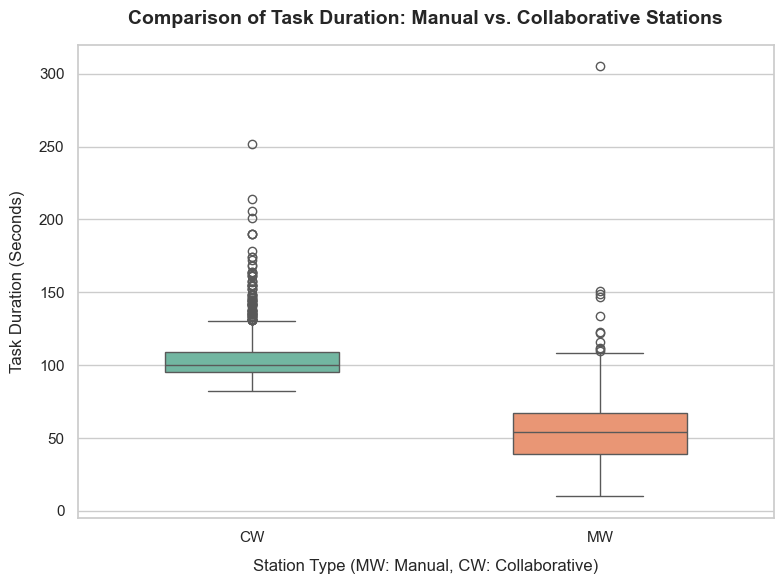

In [37]:
# Set aesthetic style for publication-ready plots
sns.set_theme(style="whitegrid")

# Set figure dimensions
plt.figure(figsize=(8, 6))

# Create a boxplot comparing task durations across workstation types
# Note: 'hue' and 'legend=False' are used to prevent Seaborn v0.14+ deprecation warnings
sns.boxplot(
    x='workstation', 
    y='total_time_sec', 
    hue='workstation',
    data=features_labeled_all, 
    palette="Set2", 
    width=0.5,
    legend=False
)

# Configure title and axis labels with academic formatting
plt.title('Comparison of Task Duration: Manual vs. Collaborative Stations', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Station Type (MW: Manual, CW: Collaborative)', fontsize=12, labelpad=10)
plt.ylabel('Task Duration (Seconds)', fontsize=12, labelpad=10)

# Optimize layout to prevent label clipping
plt.tight_layout()

# Display the plot
plt.show()

### Statistical Significance Testing (Mann-Whitney U Test)

While the boxplot provides a visual comparison of task durations between Manual (MW) and Collaborative (CW) workstations, visual inspection alone is insufficient for robust data science research. Since industrial execution times are typically non-normally distributed, we apply the non-parametric **Mann-Whitney U Test** to determine if the difference in median task durations between the two environments is statistically significant.

* **Null Hypothesis ($H_0$):** There is no significant difference in execution times between MW and CW.
* **Alternative Hypothesis ($H_A$):** There is a statistically significant difference in execution times between the two workstations.

In [13]:
from scipy.stats import mannwhitneyu

# 1. Extract task durations for each workstation type, dropping any potential NaNs
cw_times = features_labeled_all[features_labeled_all['workstation'] == 'CW']['total_time_sec'].dropna()
mw_times = features_labeled_all[features_labeled_all['workstation'] == 'MW']['total_time_sec'].dropna()

# 2. Perform the Mann-Whitney U test (Two-sided)
stat, p_value = mannwhitneyu(cw_times, mw_times, alternative='two-sided')

# 3. Print the statistical results
print("=== Statistical Hypothesis Testing Results ===")
print(f"Mann-Whitney U Test Statistic: {stat}")
print(f"P-value: {p_value:.5e}")

# 4. Interpret the P-value against the standard alpha level of 0.05
alpha = 0.05
if p_value < alpha:
    print(f"\nConclusion: Reject the Null Hypothesis (p < {alpha}).")
    print("Result: There is a statistically significant difference in execution times between Manual and Collaborative workstations.")
else:
    print(f"\nConclusion: Fail to reject the Null Hypothesis (p >= {alpha}).")
    print("Result: No statistically significant difference was observed.")

=== Statistical Hypothesis Testing Results ===
Mann-Whitney U Test Statistic: 801297.0
P-value: 2.11906e-275

Conclusion: Reject the Null Hypothesis (p < 0.05).
Result: There is a statistically significant difference in execution times between Manual and Collaborative workstations.


## STEP 8: Data Export for Machine Learning

In [14]:
# Export the final processed and labeled dataset
# Setting index=False prevents pandas from writing row numbers into the file
features_labeled_all.to_csv("../data/features_labeled_all_unified.csv", index=False)

print("Success! The unified dataset has been successfully saved to the 'data' folder.")
print(f"Final dataset shape ready for modeling: {features_labeled_all.shape}")

Success! The unified dataset has been successfully saved to the 'data' folder.
Final dataset shape ready for modeling: (1807, 16)


## 🎯 Conclusion & Next Steps (Operational Data Pipeline)

In this notebook, we successfully established the **Data Foundation** for the Hybrid Digital Twin by processing real-world industrial logs:

* **Data Integration & Robust Cleaning:** Aggregated 1,819 task-level records from both Manual (MW) and Collaborative (CW) workstations into a unified dataset, employing the Interquartile Range (IQR) method to systematically filter out extreme operational outliers.
* **Temporal Normalization:** Converted raw industrial timestamps into numerical formats and engineered the primary target variable: `total_time_sec`.
* **Statistical Verification:** Conducted Exploratory Data Analysis (EDA) supplemented by non-parametric hypothesis testing (Mann-Whitney U Test). This provided mathematical proof of significant variance in human performance across different workstations, strictly justifying the need for a non-linear predictive approach (XGBoost).
* **Methodological Integrity:** Established strict data leakage prevention protocols regarding the EDA-derived `complexity` labels to ensure the predictive engine remains unbiased.

**➡️ Next Phase:** Moving to the **Product Twin**, where we will utilize Computer Vision techniques to analyze PCB images and dynamically quantify structural complexity.
*(See Notebook: `02_product_twin_vision.ipynb`)*